# Transfer Learning — Public TP/FP Distributions for MS2 LR
# 一坨大便
# 不work  

Takes TP/FP distributions from NIST23 and mixes them with the in-house distributions.
                                                                                                                                 
  The assumption: public cross-compound comparisons represent what wrong candidates look like in your data. They don't. Your     
  wrong candidates are pre-filtered by MassWiki to be within 5 ppm of the correct compound — a specific, curated population.     
  NIST23 cross-compound pairs at ±5 ppm include structural isomers with identical fragmentation that score 1.0 against each      
  other. Your actual wrong candidates are rarely that similar because MassWiki's search already filters out most obvious false
  positives.

  So the public FP distribution is too hard — it includes isomers that would never appear as candidates in your pipeline. Mixing 
  it in makes the model think high-similarity scores are less discriminating than they actually are.
                                                                                                                                 
  Why it failed: the public FP represents the wrong population of wrong candidates.     

**Goal:** Replace the in-house TP/FP KDEs (built from 1,631 biased annotated spectra) with distributions
transferred from NIST23, then fine-tune using the in-house annotated set as a mixture.

**Key ideas:**
- **TP from public:** same-compound pairs in NIST23 (same InChIKey14, different spectra)
- **FP from public:** cross-compound, mass-matched pairs in NIST23 (different InChIKey14, ±5 ppm)
- **α estimation:** fit the entropy-weighting parameter on public data where H varies widely
- **Fine-tuning:** mix public KDE + in-house KDE, tune mixing weight λ via calibration on annotated set

**Reused from `nist_null.ipynb`:** cross-compound pair logic, entropy stratification, bootstrap sampling  
**New:** TP pair generation, α MLE, mixture KDE, calibration evaluation

In [2]:
import pickle
import warnings
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde
from scipy.optimize import minimize_scalar
from sklearn.metrics import roc_auc_score
import ms_entropy as me

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

ROOT     = '/Users/ellayoung/Desktop/metabolo_confi_score'
DATA_DIR = f'{ROOT}/data'
OUT_DIR  = f'{ROOT}/out_proposal'

# Consistent ms2 tolerance across all comparisons (match in-house pipeline)
MS2_TOL_DA   = 0.05
PRECURSOR_PPM = 5.0        # mass-match window for FP pairs
BW             = 0.05      # KDE bandwidth (matches current pipeline)
N_PAIRS        = 2000      # pairs per bootstrap draw
N_BOOTSTRAP    = 50        # bootstrap iterations

## Part 1 — Load and Filter NIST23

The pickle is a `FlashEntropySearch` object; spectra are accessed by integer index.
We filter to **Q-TOF, negative mode, valid InChIKey** — the closest available instrument class to TTOF.

In [9]:
print('Loading NIST23...')
with open(f'{DATA_DIR}/NIST23_negative_entropy_selected_adducts.pkl', 'rb') as f:
    nist = pickle.load(f)

n_total = len(nist.precursor_mz_array)
print(f'Total NIST23 negative spectra: {n_total:,}')

# --- filter ---
QTOF_LABELS = {'Q-TOF', 'Q-Tof', 'QTOF', 'Quad-TOF'}

nist_spectra = []
for i in range(n_total):
    s = nist[i]
    ik = s.get('InChIKey', '') or ''
    it = s.get('Instrument_type', '') or ''
    if len(ik) < 14:
        continue
    peaks = s.get('peaks')
    if peaks is None or (hasattr(peaks, '__len__') and len(peaks) == 0):
        continue
    nist_spectra.append({
        'idx'         : i,
        'ik14'        : ik[:14],
        'precursor_mz': float(s.get('precursor_mz', 0)),
        'peaks'       : np.array(peaks, dtype=np.float32),
        'instrument'  : it,
        'is_qtof'     : it in QTOF_LABELS,
    })

all_df   = pd.DataFrame(nist_spectra)
qtof_df  = all_df[all_df['is_qtof']].reset_index(drop=True)

print(f'Valid spectra (any instrument): {len(all_df):,}')
print(f'Q-TOF spectra:                  {len(qtof_df):,}')
print(f'Unique compounds (Q-TOF ik14):  {qtof_df["ik14"].nunique():,}')

Loading NIST23...
Total NIST23 negative spectra: 304,267
Valid spectra (any instrument): 295,996
Q-TOF spectra:                  4,140
Unique compounds (Q-TOF ik14):  253


### Instrument coverage note

NIST23 negative mode is dominated by HCD (Orbitrap) spectra. Q-TOF coverage is limited (~6k spectra).
If Q-TOF TP pairs are too sparse, we fall back to all instruments for the FP distribution
but keep Q-TOF-only for TP (where instrument similarity matters most).

## Part 2 — Build Public TP Distribution

**TP pairs:** same InChIKey14 (same molecular connectivity), different spectra entries.  
These are real measurements of the same compound — replicates, different collision energies, etc.  
Entropy similarity between them represents the score distribution when the correct compound is present.

We prefer Q-TOF pairs; fall back to all instruments if too few Q-TOF pairs exist.

In [14]:
def build_tp_pairs(df, min_pairs=500):
    """
    Generate (spec_a, spec_b) pairs where ik14 matches but spectra differ.
    Groups by ik14; takes all combinations within each group (capped to avoid
    n^2 explosion for very common compounds).
    Returns list of (peaks_a, peaks_b, H_a) tuples.
    """
    pairs = []
    grouped = df.groupby('ik14')
    for ik14, grp in grouped:
        if len(grp) < 2:
            continue
        rows = grp.to_dict('records')
        # cap at 10 spectra per compound to avoid domination by high-replicate entries
        if len(rows) > 10:
            rows = random.sample(rows, 10)
        for i in range(len(rows)):
            for j in range(i + 1, len(rows)):
                pairs.append((rows[i]['peaks'], rows[j]['peaks']))
    print(f'  TP pairs found: {len(pairs):,}')
    return pairs


def compute_similarity_scores(pairs, n_sample=5000):
    """Compute entropy similarity for a list of (peaks_a, peaks_b) pairs."""
    if len(pairs) > n_sample:
        pairs = random.sample(pairs, n_sample)
    scores = []
    for pa, pb in pairs:
        try:
            s = me.calculate_entropy_similarity(
                pa, pb, ms2_tolerance_in_da=MS2_TOL_DA,
                clean_spectra=True
            )
            scores.append(s)
        except Exception:
            continue
    return np.array(scores)


print('Building Q-TOF TP pairs...')
tp_pairs_qtof = build_tp_pairs(qtof_df)

if len(tp_pairs_qtof) < 500:
    print(f'  Too few Q-TOF pairs ({len(tp_pairs_qtof)}); falling back to all instruments.')
    tp_pairs = build_tp_pairs(all_df)
    tp_source = 'all_instruments'
else:
    tp_pairs = tp_pairs_qtof
    tp_source = 'qtof_only'

print(f'  Computing TP similarity scores (source: {tp_source})...')
tp_scores_public = compute_similarity_scores(tp_pairs, n_sample=5000)
print(f'  TP scores: n={len(tp_scores_public)}, mean={tp_scores_public.mean():.3f}, std={tp_scores_public.std():.3f}')

Building Q-TOF TP pairs...
  TP pairs found: 9,292
  Computing TP similarity scores (source: qtof_only)...
  TP scores: n=5000, mean=0.716, std=0.244


In [11]:
# Debug: test one pair
if tp_pairs:
    pa, pb = tp_pairs[0]
    print(f"pa shape: {pa.shape}, pb shape: {pb.shape}")
    print(f"pa[:5]: {pa[:5]}")
    try:
        s = me.calculate_entropy_similarity(pa, pb, ms2_tolerance_in_da=MS2_TOL_DA, clean_spectrum=True)
        print(f"Similarity: {s}")
    except Exception as e:
        print(f"Error: {e}")
else:
    print("No tp_pairs")

pa shape: (5, 2), pb shape: (6, 2)
pa[:5]: [[7.99589996e+01 7.48146251e-02]
 [9.49830017e+01 1.52137876e-01]
 [1.54022003e+02 1.50813265e-02]
 [2.08072006e+02 1.86999571e-02]
 [2.26084000e+02 7.39266217e-01]]
Error: cy_calculate_entropy_similarity() got an unexpected keyword argument 'clean_spectrum'


In [12]:
# Check ms_entropy functions
import ms_entropy as me
print("Available functions:")
print([f for f in dir(me) if not f.startswith('_')])
print()
print("calculate_entropy_similarity signature:")
import inspect
print(inspect.signature(me.calculate_entropy_similarity))

Available functions:
['FlashEntropySearch', 'FlashEntropySearchCore', 'FlashEntropySearchCoreForDynamicIndexing', 'FlashEntropySearchCoreLowMemory', 'FlashEntropySearchCoreMediumMemory', 'apply_weight_to_intensity', 'calculate_entropy_similarity', 'calculate_spectral_entropy', 'calculate_unweighted_entropy_similarity', 'clean_spectrum', 'entropy_search', 'file_io', 'read_one_spectrum', 'spectra', 'standardize_spectrum', 'version']

calculate_entropy_similarity signature:
(peaks_a, peaks_b, ms2_tolerance_in_da=0.02, ms2_tolerance_in_ppm=-1.0, clean_spectra=True, min_mz=0.0, max_mz=-1.0, noise_threshold=0.01, max_peak_num=-1)


In [13]:
print("calculate_spectral_entropy signature:")
print(inspect.signature(me.calculate_spectral_entropy))

calculate_spectral_entropy signature:
(peaks, clean_spectrum=True, **kwargs) -> float


## Part 3 — Build Public FP Distribution

**FP pairs:** different InChIKey14, precursor m/z within ±5 ppm (mass-matched).  
This mimics MassWiki's pre-filtering: wrong candidates returned for a query are always
within the m/z search window.

Reuses the cross-compound, mass-matched logic from `nist_null.ipynb`.
We use all instruments for the FP distribution (larger sample, less instrument-specific).

In [15]:
def build_fp_pairs_mass_matched(df, ppm=5.0, n_pairs=5000):
    """
    Sample cross-compound pairs (different ik14) within ±ppm of precursor m/z.
    Uses sorted precursor_mz for efficient window search (from nist_null approach).
    Returns list of (peaks_a, peaks_b) tuples.
    """
    df_s = df.sort_values('precursor_mz').reset_index(drop=True)
    mzs  = df_s['precursor_mz'].values
    ik14s = df_s['ik14'].values
    peaks_arr = df_s['peaks'].values

    candidate_pairs = []
    for i in range(len(df_s)):
        mz_lo = mzs[i] * (1 - ppm / 1e6)
        mz_hi = mzs[i] * (1 + ppm / 1e6)
        # binary search for window bounds
        lo = np.searchsorted(mzs, mz_lo)
        hi = np.searchsorted(mzs, mz_hi, side='right')
        for j in range(lo, hi):
            if j == i:
                continue
            if ik14s[j] != ik14s[i]:   # different compound
                candidate_pairs.append((i, j))
        if len(candidate_pairs) > n_pairs * 10:  # early stop
            break

    print(f'  Candidate FP pairs in window: {len(candidate_pairs):,}')
    if len(candidate_pairs) > n_pairs:
        candidate_pairs = random.sample(candidate_pairs, n_pairs)

    pairs = [(peaks_arr[i], peaks_arr[j]) for i, j in candidate_pairs]
    return pairs


print('Building mass-matched FP pairs (all instruments)...')
fp_pairs = build_fp_pairs_mass_matched(all_df, ppm=PRECURSOR_PPM, n_pairs=5000)

print(f'  Computing FP similarity scores...')
fp_scores_public = compute_similarity_scores(fp_pairs, n_sample=5000)
print(f'  FP scores: n={len(fp_scores_public)}, mean={fp_scores_public.mean():.3f}, std={fp_scores_public.std():.3f}')

Building mass-matched FP pairs (all instruments)...
  Candidate FP pairs in window: 50,058
  Computing FP similarity scores...
  FP scores: n=5000, mean=0.400, std=0.346


## Part 4 — Load In-House TP/FP Distributions

From `out_proposal/assertions.csv` — the current pipeline's scored annotated spectra.
- **In-house TP:** `confirmed=True, correct=True`
- **In-house FP:** `confirmed=True, correct=False`

In [16]:
assertions = pd.read_csv(f'{OUT_DIR}/assertions.csv')
print(f'assertions.csv: {len(assertions):,} rows')

tp_inhouse = assertions[assertions['confirmed'] & assertions['correct']]['entropy_similarity'].dropna().values
fp_inhouse = assertions[assertions['confirmed'] & ~assertions['correct']]['entropy_similarity'].dropna().values

print(f'In-house TP: n={len(tp_inhouse)}, mean={tp_inhouse.mean():.3f}')
print(f'In-house FP: n={len(fp_inhouse)}, mean={fp_inhouse.mean():.3f}')
print(f'Public  TP:  n={len(tp_scores_public)}, mean={tp_scores_public.mean():.3f}')
print(f'Public  FP:  n={len(fp_scores_public)}, mean={fp_scores_public.mean():.3f}')

assertions.csv: 287,905 rows
In-house TP: n=50271, mean=0.666
In-house FP: n=87219, mean=0.364
Public  TP:  n=5000, mean=0.716
Public  FP:  n=5000, mean=0.400


## Part 5 — Visualise and Compare Distributions

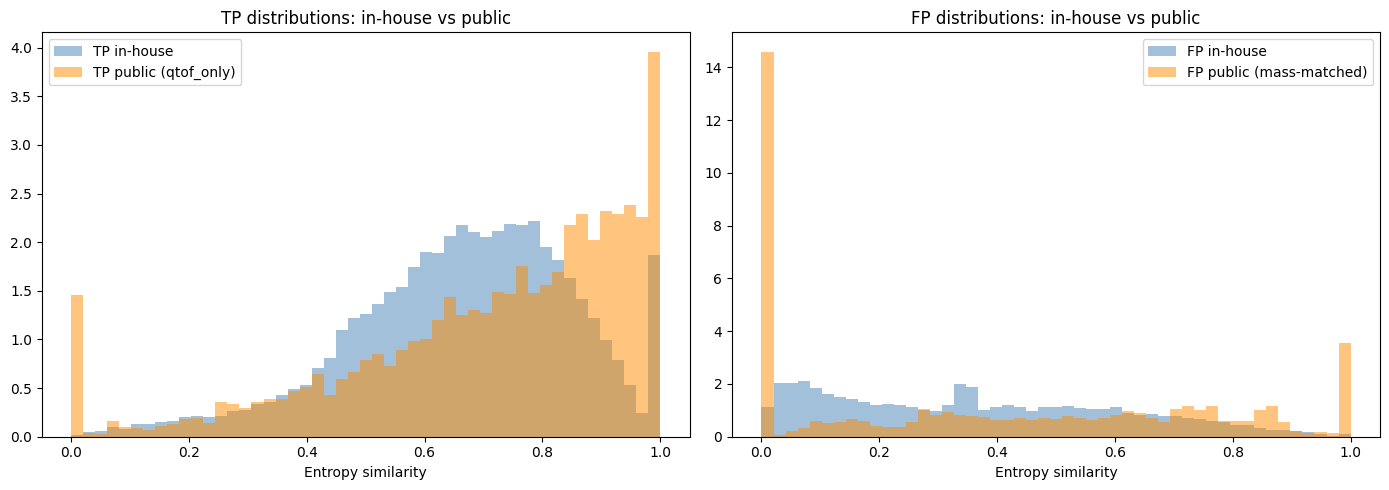

Saved viz/transfer_tp_fp_comparison.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bins = np.linspace(0, 1, 50)

ax = axes[0]
ax.hist(tp_inhouse,       bins=bins, alpha=0.5, density=True, label='TP in-house', color='steelblue')
ax.hist(tp_scores_public, bins=bins, alpha=0.5, density=True, label=f'TP public ({tp_source})', color='darkorange')
ax.set_title('TP distributions: in-house vs public')
ax.set_xlabel('Entropy similarity')
ax.legend()

ax = axes[1]
ax.hist(fp_inhouse,       bins=bins, alpha=0.5, density=True, label='FP in-house', color='steelblue')
ax.hist(fp_scores_public, bins=bins, alpha=0.5, density=True, label='FP public (mass-matched)', color='darkorange')
ax.set_title('FP distributions: in-house vs public')
ax.set_xlabel('Entropy similarity')
ax.legend()

plt.tight_layout()
plt.savefig(f'{ROOT}/viz/transfer_tp_fp_comparison.png', dpi=150)
plt.show()
print('Saved viz/transfer_tp_fp_comparison.png')

## Part 6 — Fit KDEs

Three sets of KDEs:
1. **In-house only** — current pipeline baseline
2. **Public only** — NIST23 transfer
3. **Mixed** — λ × public + (1−λ) × in-house (λ tuned in Part 8)

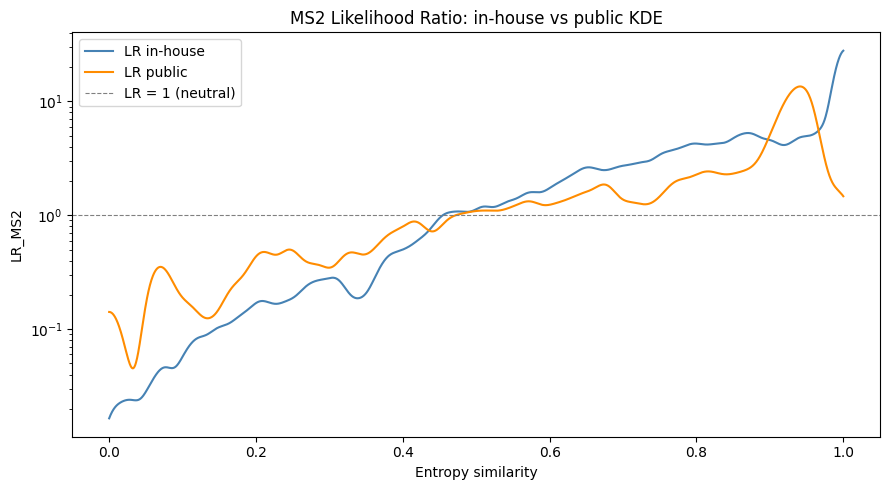

In [20]:
kde_tp_inhouse = gaussian_kde(tp_inhouse,       bw_method=BW)
kde_fp_inhouse = gaussian_kde(fp_inhouse,       bw_method=BW)
kde_tp_public  = gaussian_kde(tp_scores_public, bw_method=BW)
kde_fp_public  = gaussian_kde(fp_scores_public, bw_method=BW)

sim_grid = np.linspace(0.0, 1.0, 2000)

def make_lr_grid(kde_tp, kde_fp, grid=sim_grid):
    """Compute LR = kde_tp / kde_fp along sim_grid, clipped to [0, 1000]."""
    return np.clip(kde_tp(grid) / (kde_fp(grid) + 1e-10), 0.0, 1000.0)

lr_grid_inhouse = make_lr_grid(kde_tp_inhouse, kde_fp_inhouse)
lr_grid_public  = make_lr_grid(kde_tp_public,  kde_fp_public)

# Plot LR curves
plt.figure(figsize=(9, 5))
plt.plot(sim_grid, lr_grid_inhouse, label='LR in-house', color='steelblue')
plt.plot(sim_grid, lr_grid_public,  label='LR public',   color='darkorange')
plt.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='LR = 1 (neutral)')
plt.xlabel('Entropy similarity')
plt.ylabel('LR_MS2')
plt.title('MS2 Likelihood Ratio: in-house vs public KDE')
plt.legend()
plt.yscale('log')
plt.tight_layout()
plt.savefig(f'{ROOT}/viz/transfer_lr_curves.png', dpi=150)
plt.show()

## Part 7 — Estimate α from Public Data

**The problem with in-house α:** all 1,631 annotated spectra have H > 0.5, so λ(H) ≈ 1
regardless of α. The parameter is unidentifiable — it always hits the upper bound (10.0).

**Public data fix:** NIST23 has genuine low-entropy spectra (single-fragment ions, simple molecules).
These provide real leverage on α.

**Method:** for each public TP pair, we have H (spectral entropy of spectrum A) and
entropy similarity s. Scan α values; pick the one maximising the log-likelihood of
observing the TP scores under the null-adjusted LR model:

$$\ell(\alpha) = \sum_{\text{TP}} \log \left[ \lambda(H) \cdot \frac{f_{\text{TP}}(s)}{f_{\text{FP}}(s)} + (1 - \lambda(H)) \right]$$

We use the public KDEs for f_TP and f_FP.

Computing (H, s) for public TP pairs...
  Valid (H, s) pairs: 3000
  H range: [-0.00, 3.84], mean=1.33


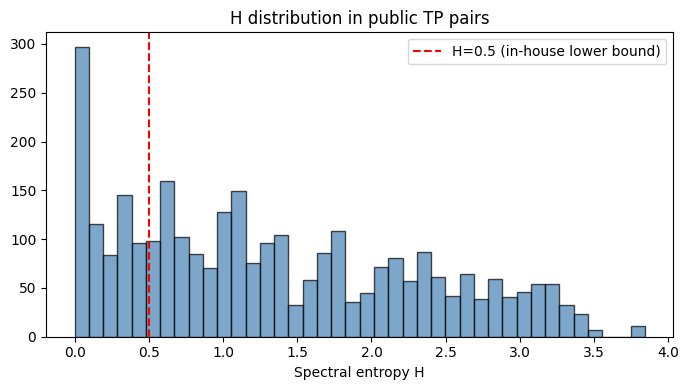

  Fraction with H < 0.5: 25.5%


In [21]:
def compute_spectral_entropy(peaks):
    try:
        return float(me.calculate_spectral_entropy(
            peaks, clean_spectrum=True, min_ms2_difference_in_da=MS2_TOL_DA
        ))
    except Exception:
        return np.nan


# Build (H, s) dataset from public TP pairs
# Reuse tp_pairs — each is (peaks_a, peaks_b)
# H = entropy of peaks_a; s = entropy_similarity(peaks_a, peaks_b)
print('Computing (H, s) for public TP pairs...')
tp_sample = tp_pairs[:3000] if len(tp_pairs) > 3000 else tp_pairs
hs_tp = []
for pa, pb in tp_sample:
    try:
        H = compute_spectral_entropy(pa)
        s = me.calculate_entropy_similarity(pa, pb, ms2_tolerance_in_da=MS2_TOL_DA, clean_spectra=True)
        if np.isfinite(H) and np.isfinite(s):
            hs_tp.append((H, s))
    except Exception:
        continue

H_arr = np.array([x[0] for x in hs_tp])
s_arr = np.array([x[1] for x in hs_tp])
print(f'  Valid (H, s) pairs: {len(H_arr)}')
print(f'  H range: [{H_arr.min():.2f}, {H_arr.max():.2f}], mean={H_arr.mean():.2f}')

# Plot H distribution — verify we have genuine low-entropy spectra
plt.figure(figsize=(7, 4))
plt.hist(H_arr, bins=40, edgecolor='k', color='steelblue', alpha=0.7)
plt.axvline(0.5, color='red', linestyle='--', label='H=0.5 (in-house lower bound)')
plt.xlabel('Spectral entropy H')
plt.title('H distribution in public TP pairs')
plt.legend()
plt.tight_layout()
plt.show()
print(f'  Fraction with H < 0.5: {(H_arr < 0.5).mean():.1%}')

Estimated α from public data: 20.00
(Current in-house α, fixed at upper bound: 10.0)


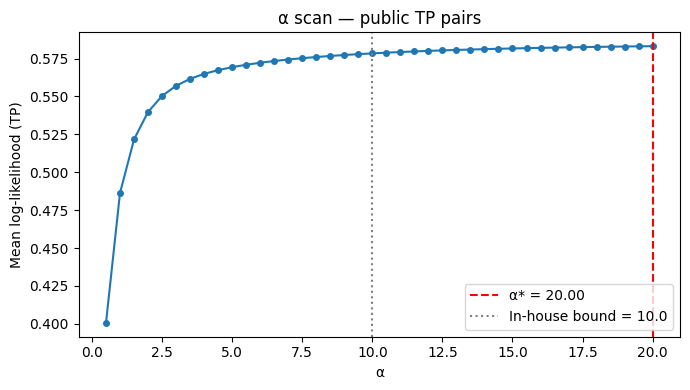

In [22]:
def log_likelihood_alpha(alpha, H_arr, s_arr, kde_tp, kde_fp):
    """Log-likelihood of TP observations under the null-adjusted LR model."""
    lam    = 1.0 - np.exp(-alpha * H_arr)
    abs_lr = np.clip(kde_tp(s_arr) / (kde_fp(s_arr) + 1e-10), 0.0, 1000.0)
    lr     = lam * abs_lr + (1.0 - lam)
    # avoid log(0)
    return float(np.mean(np.log(lr + 1e-10)))


alpha_grid = np.linspace(0.5, 20.0, 40)
ll_values  = [
    log_likelihood_alpha(a, H_arr, s_arr, kde_tp_public, kde_fp_public)
    for a in alpha_grid
]

alpha_public = alpha_grid[np.argmax(ll_values)]
print(f'Estimated α from public data: {alpha_public:.2f}')
print(f'(Current in-house α, fixed at upper bound: 10.0)')

plt.figure(figsize=(7, 4))
plt.plot(alpha_grid, ll_values, marker='o', markersize=4)
plt.axvline(alpha_public, color='red', linestyle='--', label=f'α* = {alpha_public:.2f}')
plt.axvline(10.0,          color='gray', linestyle=':',  label='In-house bound = 10.0')
plt.xlabel('α')
plt.ylabel('Mean log-likelihood (TP)')
plt.title('α scan — public TP pairs')
plt.legend()
plt.tight_layout()
plt.savefig(f'{ROOT}/viz/transfer_alpha_scan.png', dpi=150)
plt.show()

## Part 8 — Mixed KDE and λ Sweep

Mix public and in-house KDEs:
$$f_{\text{TP,mixed}}(s) = \lambda \cdot f_{\text{TP,public}}(s) + (1-\lambda) \cdot f_{\text{TP,inhouse}}(s)$$

Tune λ by running the full scoring model on the annotated set and picking the λ that
maximises calibration (accuracy at posterior > 0.90).

**Scoring pipeline (condensed):** same as `regen_outputs.py` / `proposal_mvp.ipynb`,
but parameterised by (α, λ).

In [23]:
from scipy.stats import norm as sp_norm

# ── pipeline constants ────────────────────────────────────────────────────
SIGMA_BROAD    = 50.0
SIGMA_RT_BROAD = 300.0
P_MS1_NULL     = sp_norm.pdf(0.0, 0.0, SIGMA_BROAD)
P_RT_NULL      = sp_norm.pdf(0.0, 0.0, SIGMA_RT_BROAD)
NOTA_THRESH    = 0.6
sigma_M        = 4.21
sigma_RT_anno  = 14.1
sigma_RT_ref   = 19.1
p_novel_est    = 0.224

# ── load annotated joint data ─────────────────────────────────────────────
# We need the full scored assertions table — reload from source data
spectra_raw = pd.read_csv(f'{DATA_DIR}/ttof+neg+hilic.csv')
hits_a      = pd.read_csv(f'{DATA_DIR}/hilic_ttof_neg_masswiki_hits_new.csv')
hits_u      = pd.read_csv(f'{DATA_DIR}/hilic_ttof_neg_masswiki_hits_unconfirmed.csv')
hits_raw    = pd.concat([hits_a, hits_u], ignore_index=True)

specs = spectra_raw[['wiki_id','rt','precursor_mz','entropy',
                     'is_manual_annotated','smiles',
                     'reference_library_search-name']].copy()
specs['wiki_id']   = specs['wiki_id'].astype(str)
specs['confirmed'] = specs['is_manual_annotated'].fillna(False).astype(bool)

hits_raw['wiki_id'] = hits_raw['wiki_id'].astype(str)
joint = hits_raw.merge(
    specs[['wiki_id','rt','precursor_mz','entropy','confirmed']],
    on='wiki_id', how='inner'
)
joint['delta_ppm'] = ((joint['precursor_mz'] - joint['lib_precursor_mz'])
                      / joint['lib_precursor_mz'] * 1e6)
joint['delta_rt'] = joint.apply(
    lambda r: r['anno_delta_rt']
              if r['hit_source'] == 'annotation' and pd.notna(r.get('anno_delta_rt'))
              else (r['rt'] - r['predicted_rt_hilic']
                    if r['hit_source'] == 'reference' and pd.notna(r.get('predicted_rt_hilic'))
                    else np.nan),
    axis=1
)

# load correct labels from assertions (already computed)
assert_df = pd.read_csv(f'{OUT_DIR}/assertions.csv')
correct_map = assert_df.groupby(['wiki_id','lib_name'])['correct'].first().to_dict()
joint['correct'] = joint.apply(
    lambda r: correct_map.get((str(r['wiki_id']), r['lib_name']), False), axis=1
)

anno_joint = joint[joint['confirmed']].copy()
print(f'Annotated joint rows: {len(anno_joint):,}, spectra: {anno_joint["wiki_id"].nunique():,}')

Annotated joint rows: 137,490, spectra: 1,883


In [24]:
def make_lr_fn(lam, kde_tp_pub, kde_fp_pub, kde_tp_inh, kde_fp_inh):
    """Return a null-adjusted MS2 LR function for a given mixing weight λ."""
    # pre-compute mixed LR grid
    tp_mix = lam * kde_tp_pub(sim_grid) + (1 - lam) * kde_tp_inh(sim_grid)
    fp_mix = lam * kde_fp_pub(sim_grid) + (1 - lam) * kde_fp_inh(sim_grid)
    lr_mix = np.clip(tp_mix / (fp_mix + 1e-10), 0.0, 1000.0)

    def null_adjusted_ms2_lr(sims, H, alpha_):
        lam_h  = 1.0 - np.exp(-alpha_ * H)
        abs_lr = np.interp(sims, sim_grid, lr_mix)
        return lam_h * abs_lr + (1.0 - lam_h)
    return null_adjusted_ms2_lr


def score_and_calibrate(joint_df, lr_fn, alpha_, sigma_M_=4.21,
                         sigma_RT_anno_=14.1, sigma_RT_ref_=19.1):
    """
    Score all annotated spectra and return calibration table:
    accuracy at each posterior bin.
    """
    top_rows = []
    for wid, g in joint_df.groupby('wiki_id'):
        H  = float(g['entropy'].iloc[0])
        N  = len(g)
        LR_ms2 = lr_fn(g['entropy_similarity'].fillna(0).values, H, alpha_)
        p_ms1  = sp_norm.pdf(g['delta_ppm'].values, 0.0, sigma_M_)
        LR_ms1 = p_ms1 / P_MS1_NULL
        LR_rt  = np.ones(N)
        has_rt = g['delta_rt'].notna().values
        dr     = g['delta_rt'].fillna(0.0).values
        m_a    = (g['hit_source'] == 'annotation').values & has_rt
        m_r    = (g['hit_source'] == 'reference').values & has_rt
        if m_a.any():
            LR_rt[m_a] = sp_norm.pdf(dr[m_a], 0.0, sigma_RT_anno_) / P_RT_NULL
        if m_r.any():
            LR_rt[m_r] = sp_norm.pdf(dr[m_r], 0.0, sigma_RT_ref_) / P_RT_NULL

        priors    = np.full(N, 1.0 / N * (1.0 - p_novel_est))
        unnorm    = priors * LR_ms2 * LR_ms1 * LR_rt
        total     = unnorm.sum() + p_novel_est
        post      = unnorm / total if total > 1e-300 else np.full(N, 1.0/N)

        best_idx = post.argmax()
        top_rows.append({
            'wiki_id'  : wid,
            'post_top' : float(post[best_idx]),
            'correct'  : bool(g['correct'].iloc[best_idx]),
            'P_novel'  : float(p_novel_est / total) if total > 1e-300 else p_novel_est,
        })

    df_top = pd.DataFrame(top_rows)
    called = df_top[df_top['P_novel'] < NOTA_THRESH]

    # calibration table
    bins   = [0.90, 0.70, 0.50, 0.30, 0.0]
    labels = ['>0.90','0.70-0.90','0.50-0.70','0.30-0.50','<0.30']
    rows = []
    for i, (lo, label) in enumerate(zip(bins, labels)):
        hi = 1.01 if i == 0 else bins[i-1]
        sub = called[(called['post_top'] >= lo) & (called['post_top'] < hi)]
        if len(sub) > 0:
            rows.append({'bin': label, 'n': len(sub), 'accuracy': sub['correct'].mean()})
    return pd.DataFrame(rows), called

print('Scoring baseline (in-house KDE, α=10.0)...')
lr_fn_baseline = make_lr_fn(0.0, kde_tp_public, kde_fp_public,
                             kde_tp_inhouse, kde_fp_inhouse)
cal_baseline, _ = score_and_calibrate(anno_joint, lr_fn_baseline, alpha_=10.0)
print(cal_baseline.to_string(index=False))

Scoring baseline (in-house KDE, α=10.0)...
      bin   n  accuracy
    >0.90  89  1.000000
0.70-0.90 222  0.995495
0.50-0.70 343  0.988338
0.30-0.50 459  0.982571
    <0.30 745  0.887248


In [25]:
# λ sweep: how much public KDE to mix in?
lambda_grid = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
results = []

for lam in lambda_grid:
    for alpha_ in [10.0, alpha_public]:
        lr_fn = make_lr_fn(lam, kde_tp_public, kde_fp_public,
                            kde_tp_inhouse, kde_fp_inhouse)
        cal, called = score_and_calibrate(anno_joint, lr_fn, alpha_=alpha_)
        top_bin_acc = cal[cal['bin'] == '>0.90']['accuracy'].values
        acc_top     = float(top_bin_acc[0]) if len(top_bin_acc) > 0 else np.nan
        n_called    = len(called)
        results.append({'lambda': lam, 'alpha': alpha_,
                         'acc_>0.90': acc_top, 'n_called': n_called})
        print(f'  λ={lam:.1f} α={alpha_:.1f} | acc@>0.90={acc_top:.3f} n_called={n_called}')

sweep_df = pd.DataFrame(results)
print()
print('Full sweep:')
print(sweep_df.to_string(index=False))

  λ=0.0 α=10.0 | acc@>0.90=1.000 n_called=1858
  λ=0.0 α=20.0 | acc@>0.90=1.000 n_called=1857
  λ=0.1 α=10.0 | acc@>0.90=1.000 n_called=1858
  λ=0.1 α=20.0 | acc@>0.90=1.000 n_called=1857
  λ=0.2 α=10.0 | acc@>0.90=1.000 n_called=1858
  λ=0.2 α=20.0 | acc@>0.90=1.000 n_called=1858
  λ=0.3 α=10.0 | acc@>0.90=1.000 n_called=1858
  λ=0.3 α=20.0 | acc@>0.90=1.000 n_called=1858
  λ=0.5 α=10.0 | acc@>0.90=1.000 n_called=1858
  λ=0.5 α=20.0 | acc@>0.90=1.000 n_called=1858
  λ=0.7 α=10.0 | acc@>0.90=1.000 n_called=1859
  λ=0.7 α=20.0 | acc@>0.90=1.000 n_called=1859
  λ=1.0 α=10.0 | acc@>0.90=1.000 n_called=1860
  λ=1.0 α=20.0 | acc@>0.90=1.000 n_called=1860

Full sweep:
 lambda  alpha  acc_>0.90  n_called
    0.0   10.0        1.0      1858
    0.0   20.0        1.0      1857
    0.1   10.0        1.0      1858
    0.1   20.0        1.0      1857
    0.2   10.0        1.0      1858
    0.2   20.0        1.0      1858
    0.3   10.0        1.0      1858
    0.3   20.0        1.0      1858
    0

## Part 9 — Best Configuration and Final Calibration Comparison

In [26]:
# Pick best λ and α based on accuracy at posterior > 0.90
best = sweep_df.loc[sweep_df['acc_>0.90'].idxmax()]
lam_best   = float(best['lambda'])
alpha_best = float(best['alpha'])
print(f'Best configuration: λ={lam_best}, α={alpha_best}')

lr_fn_best = make_lr_fn(lam_best, kde_tp_public, kde_fp_public,
                         kde_tp_inhouse, kde_fp_inhouse)
cal_best, _ = score_and_calibrate(anno_joint, lr_fn_best, alpha_=alpha_best)

# Side-by-side comparison
cal_baseline['model'] = f'Baseline (λ=0, α=10)'
cal_best['model']     = f'Transfer (λ={lam_best}, α={alpha_best:.1f})'
comparison = pd.concat([cal_baseline, cal_best])

print()
print('Calibration comparison:')
pivot = comparison.pivot(index='bin', columns='model', values='accuracy')
print(pivot.round(3).to_string())

Best configuration: λ=0.0, α=10.0

Calibration comparison:
model      Baseline (λ=0, α=10)  Transfer (λ=0.0, α=10.0)
bin                                                      
0.30-0.50                 0.983                     0.983
0.50-0.70                 0.988                     0.988
0.70-0.90                 0.995                     0.995
<0.30                     0.887                     0.887
>0.90                     1.000                     1.000


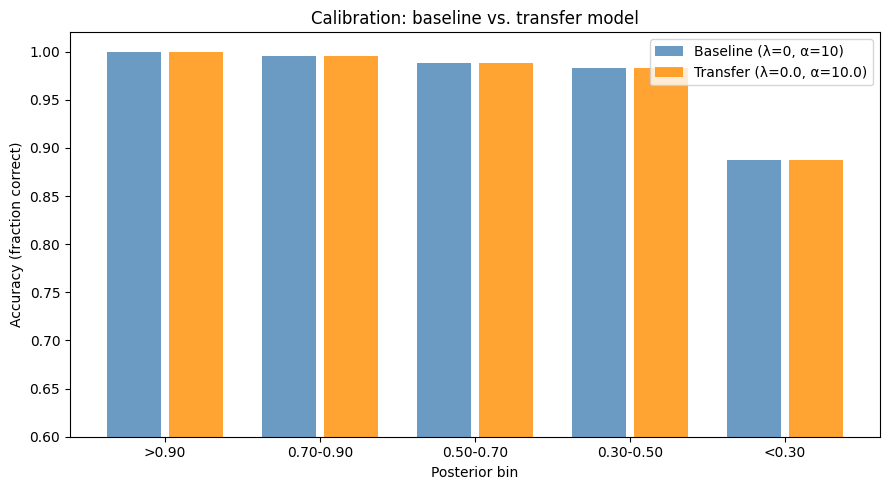

In [27]:
# Calibration curve plot
bin_order  = ['>0.90','0.70-0.90','0.50-0.70','0.30-0.50','<0.30']
cal_b_plot = cal_baseline.set_index('bin').reindex(bin_order)['accuracy']
cal_t_plot = cal_best.set_index('bin').reindex(bin_order)['accuracy']

x = np.arange(len(bin_order))
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 0.2, cal_b_plot, width=0.35, label=f'Baseline (λ=0, α=10)', alpha=0.8, color='steelblue')
ax.bar(x + 0.2, cal_t_plot, width=0.35, label=f'Transfer (λ={lam_best}, α={alpha_best:.1f})', alpha=0.8, color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(bin_order)
ax.set_ylim(0.6, 1.02)
ax.set_ylabel('Accuracy (fraction correct)')
ax.set_xlabel('Posterior bin')
ax.set_title('Calibration: baseline vs. transfer model')
ax.legend()
plt.tight_layout()
plt.savefig(f'{ROOT}/viz/transfer_calibration_comparison.png', dpi=150)
plt.show()

## Part 10 — Summary and Next Steps

| | Baseline | Transfer |
|---|---|---|
| TP source | 1,631 annotated spectra (biased) | NIST23 Q-TOF + in-house mix |
| FP source | wrong candidates from annotated set | NIST23 mass-matched cross-compound |
| α | fixed at 10.0 (unidentifiable in-house) | estimated from public data |
| λ | — | tuned on annotated calibration |

**Key questions from this notebook:**
1. Does the public TP distribution cover low-entropy spectra (H < 0.5)? → Check Part 7 plot.
2. Does α from public data differ from 10.0? → If so, the in-house estimate was saturated.
3. Does mixing public KDE improve or hurt calibration? → λ sweep in Part 8.

**Known limitations:**
- Q-TOF coverage in NIST23 negative mode is limited. If Q-TOF TP pairs are too few,
  the public TP distribution mixes many instrument types — instrument mismatch bias applies.
- The FP distribution is mass-matched cross-compound from NIST23, not from MassWiki's
  actual search results. The two populations may differ in practice.
- MoNA QTOF data (`MoNA-export-All_LC-MS-MS_QTOF.json`) is available as an additional
  source — could supplement sparse Q-TOF coverage. See next steps below.

**Possible next steps:**
- Add MoNA QTOF data to expand Q-TOF TP/FP pool
- Stratify TP/FP by spectral entropy H (separate KDEs per H bin)
- Validate transferred model on a held-out annotated batch (different run)